# Gaussian Mixture Model Thresholding

This notebook demonstrates the `GaussianMixtureModelThresholding` class from the `cc_mapping` package. This class provides a flexible, semi-supervised approach to categorizing samples based on continuous features using Gaussian Mixture Models (GMMs).

## Key Features

- **Automatic threshold determination**: Fit GMMs and automatically calculate decision boundaries
- **Manual threshold override**: Specify custom thresholds while leveraging GMM visualization
- **Label collapsing**: Fit many GMM components for adaptive boundaries, then collapse to fewer categories for robustness
- **Exploratory visualization**: Explore your data distributions before committing to thresholding
- **Comprehensive visualization**: Multiple plotting methods to understand your data and thresholds

## Table of Contents

1. [Setup and Data Loading](#setup)
2. [Exploratory Data Analysis](#exploratory)
3. [Basic Usage: Automatic Thresholding](#basic-usage)
4. [Manual Threshold Override](#manual-thresholds)
5. [Retrieving Results](#results)
6. [Additional Examples](#additional-examples)

In [20]:
# Import all required libraries
from pathlib import Path
from urllib.request import urlretrieve

import anndata as ad
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import sys

sys.path.append("R:\Dante\git\cc_mapping\src")

from cc_mapping.thresholding import GaussianMixtureModelThresholding
from cc_mapping.thresholding import create_boolean_label_combination
from cc_mapping.thresholding import generate_thresholding_report

%matplotlib inline

<a id="setup"></a>
## 1. Setup and Data Loading

First, import the required libraries and load the example dataset.

In [21]:
url = "https://zenodo.org/records/4525425/files/control_manifold_allfeatures.csv?download=1"

cwd = Path.cwd()

download_path = cwd / "data" / "control_manifold_allfeatures.csv"

if not download_path.parent.exists():
    download_path.parent.mkdir(parents=True)
    urlretrieve(url, download_path)

In [22]:
# Create results directory structure for saving figures
results_dir = cwd / "results"
single_results_dir = results_dir / "single"

# Create directories if they don't exist
results_dir.mkdir(exist_ok=True)
single_results_dir.mkdir(exist_ok=True)

print(f"Results directory created at: {results_dir}")
print(f"Single threshold results directory: {single_results_dir}")

Results directory created at: c:\Users\dap182\Documents\git\cc_mapping\notebooks\results
Single threshold results directory: c:\Users\dap182\Documents\git\cc_mapping\notebooks\results\single


### Results Directory Setup

All plotting functions now support an optional `save_path` parameter to automatically save figures. The parent directory must exist before saving, so we create the directory structure here.

### Download Example Dataset

Download the control manifold dataset from Zenodo.

In [23]:
csv = pd.read_csv(download_path, index_col=0, low_memory=False)
csv.index = csv.index.astype(str)
csv.head()

,E2F1 (nuc median),cycA (nuc median),cycD1 (nuc median),p21 (nuc median),Int_Intg_DNA_nuc,Skp2 (nuc median),Cdt1 (nuc median),Nuc area,Cdh1 (nuc median),cycE (nuc median),...,STAT3 (phospho/total nuc),age,phase,PHATE_1,PHATE_2,PCNA foci,DNA content,Local cell density,annotated age,annotated phase
Unnamed: 0.1.1,,,,,,,,,,,,,,,,,,,,,
0,0.006851,0.005875,0.019471,0.026032,5.746899,0.006493,0.005158,553.0,0.014336,0.009262,...,1.770186,10.263173,G1,-0.020654,0.007907,0.005151,2.298759,7.0,NaN,NaN
1,0.012360,0.028153,0.007462,0.004318,8.852262,0.022797,0.005951,490.0,0.015229,0.008392,...,1.455814,12.109644,S,0.025945,-0.000735,0.006861,3.540905,1.0,NaN,NaN
2,0.007279,0.005707,0.006592,0.003632,4.951003,0.015366,0.004929,363.0,0.005730,0.009117,...,1.290323,4.954907,G1,0.002961,-0.004575,0.004148,1.980401,6.0,NaN,NaN
3,0.006531,0.016602,0.009369,0.006264,10.466743,0.019196,0.005234,579.0,0.009361,0.007118,...,1.435065,13.424587,G2,0.034884,0.002944,0.002457,4.186697,9.0,NaN,NaN
5,0.006744,0.006027,0.009033,0.005295,5.249119,0.010422,0.007797,296.0,0.008896,0.007767,...,1.266304,1.828240,G1,-0.019039,0.000584,0.003277,2.099648,3.0,NaN,NaN


### Load and Preview Data

In [24]:
# convert the dataframe into an anndata object
# ensure the data is not of object type (e.g. contains strings)
adata = ad.AnnData(
    X=csv.values[:,:-10].astype(np.float32),
)
adata.var_names = csv.columns.values[:-10]

In [25]:
list(adata.var_names)

['E2F1 (nuc median)',
 'cycA (nuc median)',
 'cycD1 (nuc median)',
 'p21 (nuc median)',
 'Int_Intg_DNA_nuc',
 'Skp2 (nuc median)',
 'Cdt1 (nuc median)',
 'Nuc area',
 'Cdh1 (nuc median)',
 'cycE (nuc median)',
 'PCNA (nuc median)',
 'pH2AX (nuc median)',
 'cMyc (nuc median)',
 'RB (nuc median)',
 'cycB1 (cell median)',
 'cycB1 (cyto median)',
 'cycB1 (PN median)',
 'pRB (nuc median)',
 'cycB1 (nuc median)',
 'p27 (nuc median)',
 'ERK (nuc median)',
 'pp53 (nuc median)',
 'S6 (nuc median)',
 'cycB1 (PM median)',
 'pp21 (nuc median)',
 'CDK2 (nuc median)',
 'CDK4 (nuc median)',
 'DNA (nuc median)',
 'cFos (nuc median)',
 'Cell area',
 'Fra1 (PM median)',
 'CDK6 (nuc median)',
 'p16 (nuc median)',
 'cycD1 (cyto median)',
 'GSK3b (nuc median)',
 'p38 (nuc median)',
 'Bcl2 (nuc median)',
 'CDK2 (cyto median)',
 'Skp2 (PM median)',
 'cycA (cell median)',
 'Skp2 (cell median)',
 'cycA (PN median)',
 'cycD1 (cell median)',
 'pp65 (nuc median)',
 'YAP (nuc median)',
 'pSTAT3 (nuc median)',
 'CD

### Convert to AnnData Format

<a id="exploratory"></a>
## 2. Exploratory Data Analysis

Before performing GMM thresholding, it's helpful to explore your data distribution. The `GaussianMixtureModelThresholding` class provides exploratory plotting methods that let you visualize distributions **without** running any thresholding operations.

This is useful for:
- Understanding the shape of your data distribution
- Deciding how many GMM components to use
- Determining appropriate manual threshold values
- Identifying potential data quality issues

### Initialize GMM Object for Exploration

First, create a GMM thresholding object to explore the 'cycD1 (nuc median)' feature:

In [26]:
# Initialize the GMM thresholding object for exploration
# Note: We don't need to fit() or categorize_samples() yet for exploratory plots
gmm_explore = GaussianMixtureModelThresholding(
    adata=adata, 
    feature='cycD1 (nuc median)',
    label_obs_save_str='cell_cycle_explore'
)

### Plot 1: Histogram Distribution (Exploratory)

The simplest way to visualize your feature distribution is with a histogram. This helps you understand the shape and spread of your data:

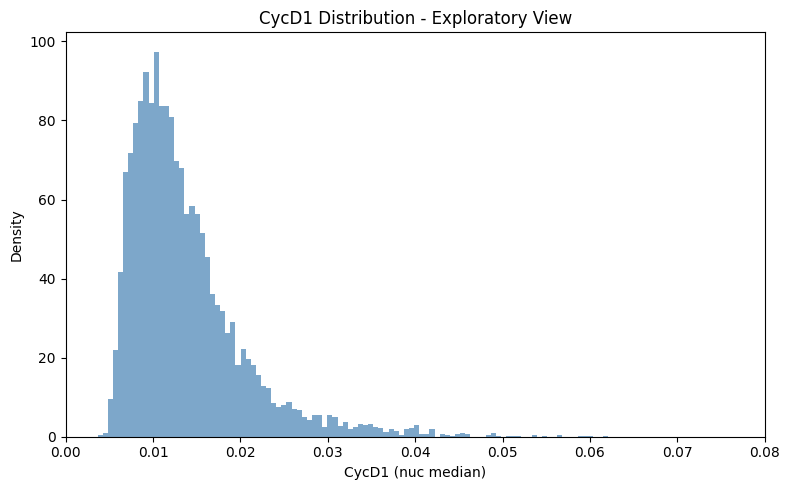

In [27]:
# Plot histogram without any thresholding
fig, ax = plt.subplots(figsize=(8, 5))

gmm_explore.plot_feature_distribution_exploratory(
    hist_kwargs={'bins': 100, 'color': 'steelblue', 'alpha': 0.7},
    x_axis_limits=(0, 0.08),
    ax=ax
)

ax.set_title('CycD1 Distribution - Exploratory View')
ax.set_xlabel('CycD1 (nuc median)')
ax.set_ylabel('Density')
plt.tight_layout()
plt.show()

### Plot 2: Strip Plot with Density (Exploratory)

For a more detailed view that shows individual cell distributions and density patterns, use the strip plot visualization:

C:\Users\dap182\AppData\Local\Temp\ipykernel_14728\1907561094.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


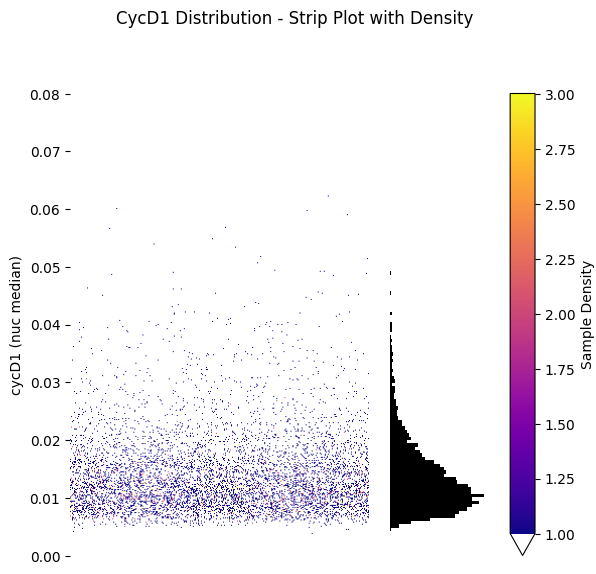

In [28]:
# Plot strip plot with density coloring (no thresholding yet)
fig, (ax_strip, ax_hist) = gmm_explore.plot_feature_strip_plot_exploratory(
    scatter_density=True,
    x_axis_limits=(0, 0.08),
    hist_kwargs={'bins': 100, 'color': 'black'}
)

plt.suptitle('CycD1 Distribution - Strip Plot with Density', y=1.02)
plt.tight_layout()
plt.show()

### Key Observations from Exploratory Plots

From these exploratory visualizations, you can:

1. **Identify peaks**: The distribution appears to have 2 distinct peaks, suggesting 2 GMM components may be appropriate
2. **Assess spread**: The data spans roughly from 0 to 0.08
3. **Spot outliers**: Check for any unusual patterns or extreme values
4. **Estimate thresholds**: If using manual thresholds, you might place one around 0.03-0.04 where the valley between peaks occurs

Now that we've explored the data, let's proceed with actual thresholding!

The optimal number of components is 2


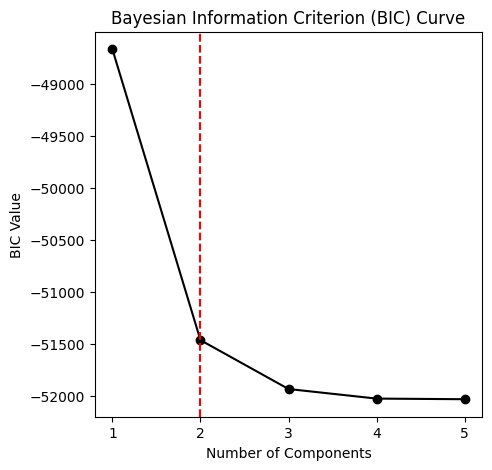

In [29]:
# initialize the gmm thresholding object with the adata object and the feature of interest
gmm_kwargs = {'init_params': 'k-means++', 'n_init':10, 'max_iter':1000}

gmm_thresholding = GaussianMixtureModelThresholding(adata= adata, 
                                                    feature = 'cycD1 (nuc median)',
                                                    label_obs_save_str= 'Low/High DNA Content',
                                                    gmm_kwargs = gmm_kwargs)

# plot the bayesian information criterion curve to determine the optimal number of components
component_range = 5
gmm_thresholding.plot_bayesian_information_criterion_curve(
    component_range=component_range,
)

# the optimal number of components can be calculated without plotting as well
optimal_component_number = gmm_thresholding.determine_optimal_number_components(component_range=component_range)
print(f'The optimal number of components is {optimal_component_number}')

#fit the GMM with the optimal number of components
gmm_thresholding.fit(n_components=optimal_component_number)

<a id="basic-usage"></a>
## 3. Basic Usage: Automatic Thresholding

The most common workflow involves:
1. Initialize the thresholding object with your data and feature of interest
2. Determine the optimal number of GMM components using BIC
3. Fit the GMM with the optimal number of components
4. Categorize samples using automatically calculated decision boundaries

In [30]:
# Categorize samples using automatically calculated decision boundaries from the fitted GMM
# The ordered_labels parameter specifies the labels from low to high feature values
gmm_thresholding.categorize_samples(ordered_labels=['Low', 'High'])

Figure saved to: c:\Users\dap182\Documents\git\cc_mapping\notebooks\results\single\basic_threshold_histogram.png


<Axes: title={'center': 'cycD1 (nuc median)'}, xlabel='cycD1 (nuc median)', ylabel='Density'>

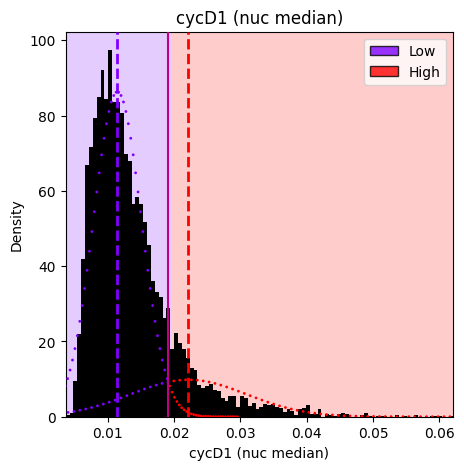

In [31]:

gmm_thresholding.plot_hist_distribution_with_boundaries(
    resolution=100,
    save_path=single_results_dir / 'basic_threshold_histogram.png'  # Optional: save the figure
)

### Visualize the Results

Plot the feature distribution with the decision boundaries.

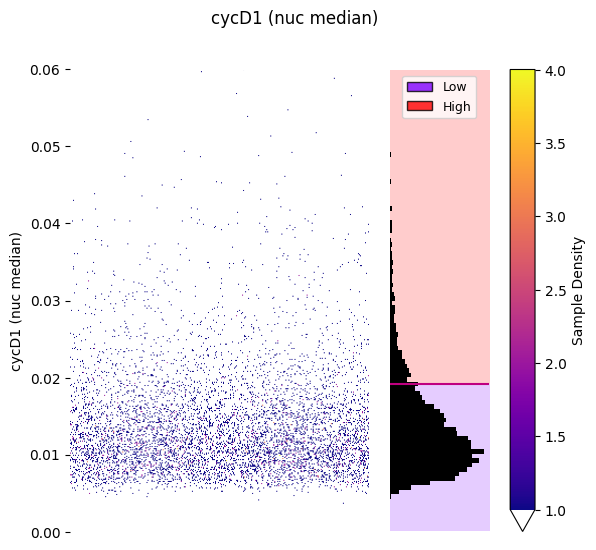

In [32]:
#plots a strip plot with the labeled histogram and the decision boundaries, coloring by sample density
hist_kwargs = {"bins": 100, 'color': 'black'}
# Note: vmax is set to match the exploratory plot's auto-calculated range for consistent colorbars
gmm_thresholding.plot_strip_plot_histogram_with_decision_boundaries(hist_kwargs=hist_kwargs, vmax=4, y_axis_limits=(0,0.06));

Visualize with a strip plot, coloring points by sample density:

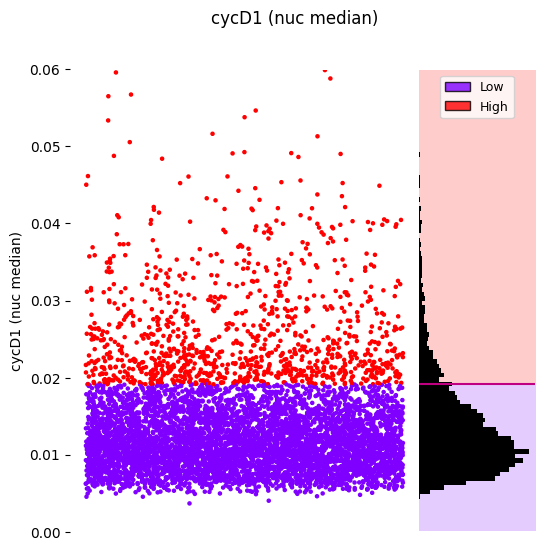

In [33]:
#plots a strip plot with the labeled histogram and the decision boundaries, coloring by sample labels
hist_kwargs = {"bins": 100, 'color': "black"}
gmm_thresholding.plot_strip_plot_histogram_with_decision_boundaries(y_axis_limits=(0,0.06),
                                                                    hist_kwargs=hist_kwargs,
                                                                    scatter_density=False,
                                                                    );

Or color points by their assigned labels:

<a id="manual-thresholds"></a>
## 5. Manual Threshold Override

You can override the automatically calculated thresholds by specifying `manual_thresholds`. This is useful when you want to apply consistent thresholds across multiple datasets, or when you have domain knowledge about appropriate cutoff values.

Let's reinitialize and demonstrate manual threshold setting:

<Axes: title={'center': 'cycD1 (nuc median)'}, xlabel='cycD1 (nuc median)', ylabel='Density'>

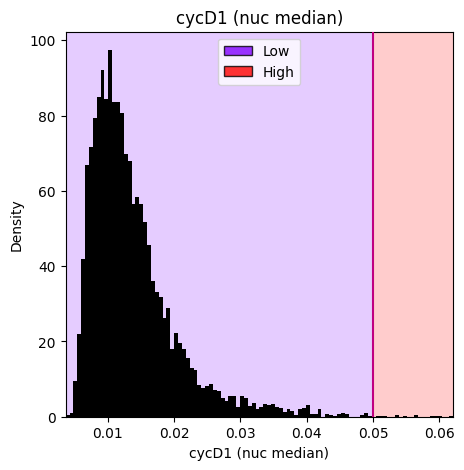

In [34]:
# Reinitialize to demonstrate manual thresholds
gmm_thresholding_manual = GaussianMixtureModelThresholding(
    adata=adata, 
    feature='cycD1 (nuc median)',
    label_obs_save_str='Manual Low/High DNA Content',
    gmm_kwargs=gmm_kwargs
)

# Fit the GMM (still useful for visualization even when using manual thresholds)
gmm_thresholding_manual.fit(n_components=optimal_component_number)

# Categorize with manual threshold at 0.05
# The manual_thresholds parameter overrides automatic boundary calculation
gmm_thresholding_manual.categorize_samples(
    ordered_labels=['Low', 'High'], 
    manual_thresholds=[0.05]
)

# Visualize to see the manually set threshold
gmm_thresholding_manual.plot_hist_distribution_with_boundaries(resolution=100)

<a id="results"></a>
## 5. Retrieving Results

After categorization, you can retrieve the updated AnnData object and access the stored thresholding information.

In [35]:
adata = gmm_thresholding.return_adata()
adata

AnnData object with n_obs × n_vars = 6797 × 289
    obs: 'Low/High DNA Content'
    uns: 'gmm_thresholding_events'

The thresholding metadata is stored in `adata.uns['gmm_thresholding_events']`:

## 6. Utility Functions

The `cc_mapping.thresholding` module provides standalone utility functions for common operations.

### 6.1 Generate Thresholding Report

Generate a summary report of thresholding operations:

In [36]:
# Generate a text report
report = generate_thresholding_report(
    adata, 
    thresholding_events_key='gmm_thresholding_events',
    output_format='text'
)
print(report)

Thresholding Report

1. cycD1 (nuc median) (Standard Thresholding)
---------------------------------------------
   Feature: cycD1 (nuc median)
   Layer: None
   Obs column: Low/High DNA Content
   Components: 2
   Thresholds: [0.0191]
   Labels: ['Low', 'High']
   Cell counts: Low=5744, High=1053

Total operations: 1
Operation types:
  - standard: 1


You can also generate the report as a pandas DataFrame for further analysis:

In [37]:
# Generate a DataFrame report
report_df = generate_thresholding_report(
    adata,
    thresholding_events_key='gmm_thresholding_events',
    output_format='dataframe'
)
display(report_df)

,Operation,Type,Feature,Layer,Obs Label,Components,Thresholds,Labels,Parent,Refined From,Total Cells
0,1. cycD1 (nuc median),standard,cycD1 (nuc median),None,Low/High DNA Content,2,0.0191,"Low, High",None,N/A,6797


### 6.2 Boolean Label Combination

Combine categorical labels with boolean operators for advanced filtering. This example demonstrates combining the GMM-generated `'Low/High DNA Content'` label with a synthetic `'treatment'` label.

In [ ]:
# Create a synthetic treatment label for demonstration
np.random.seed(42)
n_cells = len(adata)
adata.obs['treatment'] = pd.Categorical(
    np.random.choice(['control', 'drug_A', 'drug_B'], size=n_cells)
)

# Combine two categorical labels using boolean operators
# operator options: 'AND', 'OR', 'XOR'
adata = create_boolean_label_combination(
    adata,
    label1='treatment',
    label1_values=['control'],
    label2='Low/High DNA Content',
    label2_values=['High'],
    operator='AND',  
    output_label='control_and_high_DNA',
    positive_label='control_with_high_DNA',
    negative_label='other',
    overwrite=False  # Default: raises error if output_label already exists
)

print("Combined label distribution:")
print(adata.obs['control_and_high_DNA'].value_counts())

Combined label distribution:
control_and_high_DNA
other                    6455
control_with_high_DNA     342
Name: count, dtype: int64
